# ChurnGuard - Customer Churn Prediction

**Dataset:** Telco Customer Churn (7,043 customers)  
**Source:** [Kaggle - Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)  
**Goal:** Predict which customers are likely to churn and identify the key factors driving customer attrition.

---

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

matplotlib.rcParams['font.family']        = 'DejaVu Sans'
matplotlib.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')
plt.rcParams['font.size'] = 12

OUT = 'outputs'
print('Libraries loaded!')

Libraries loaded!


## 2. Load & Explore Data

In [2]:
df = pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Fix TotalCharges column
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

print(f'Shape        : {df.shape}')
print(f'Churned      : {(df["Churn"] == "Yes").sum()}')
print(f'Not Churned  : {(df["Churn"] == "No").sum()}')
print(f'Churn Rate   : {(df["Churn"] == "Yes").mean()*100:.1f}%')
df.head()

Shape        : (7043, 21)
Churned      : 1869
Not Churned  : 5174
Churn Rate   : 26.5%


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Exploratory Data Analysis

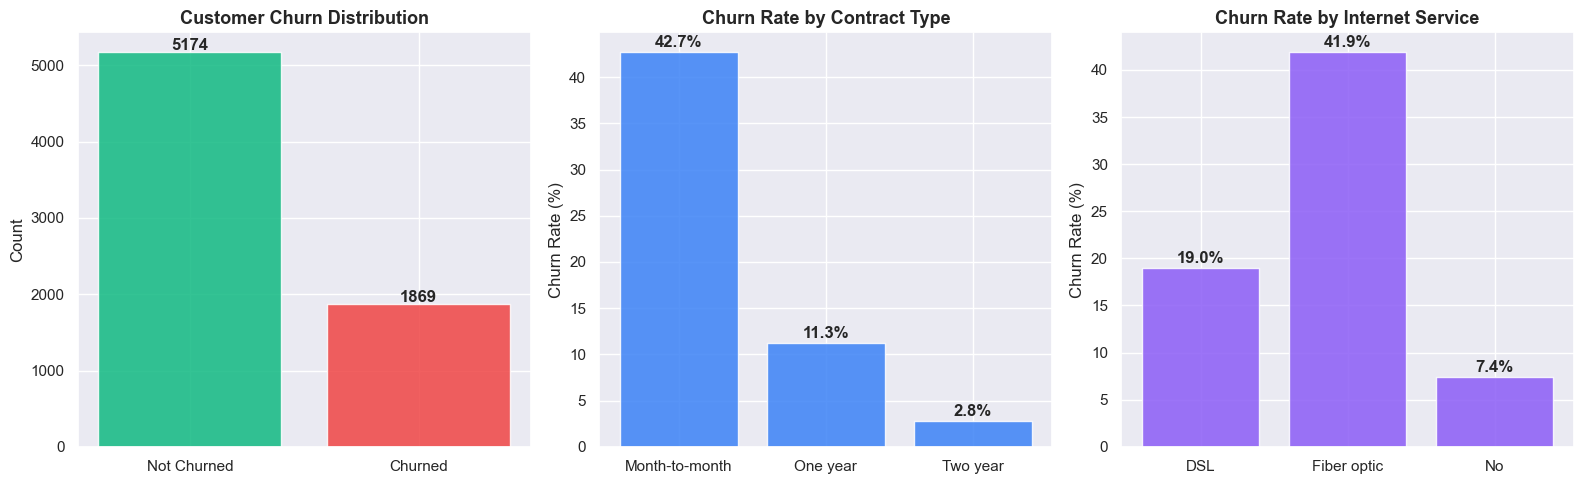

In [3]:
# Churn Overview
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Churn Distribution
churn_counts = df['Churn'].value_counts()
axes[0].bar(['Not Churned', 'Churned'], churn_counts.values, color=['#10b981', '#ef4444'], alpha=0.85)
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')
axes[0].set_title('Customer Churn Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')

# Churn by Contract Type
contract_churn = df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
axes[1].bar(contract_churn.index, contract_churn.values, color='#3b82f6', alpha=0.85)
for i, v in enumerate(contract_churn.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')
axes[1].set_title('Churn Rate by Contract Type', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')

# Churn by Internet Service
internet_churn = df.groupby('InternetService')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
axes[2].bar(internet_churn.index, internet_churn.values, color='#8b5cf6', alpha=0.85)
for i, v in enumerate(internet_churn.values):
    axes[2].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')
axes[2].set_title('Churn Rate by Internet Service', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Churn Rate (%)')

plt.tight_layout()
plt.savefig(f'{OUT}/churn_overview.png', dpi=150)
plt.show()

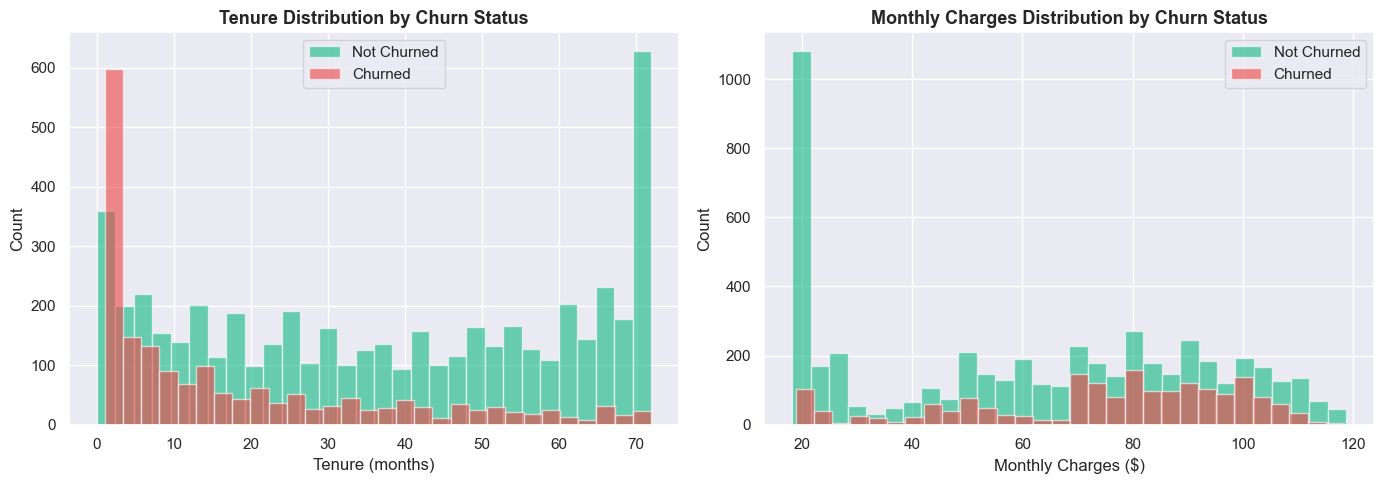

In [4]:
# Tenure and Charges by Churn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

churned     = df[df['Churn'] == 'Yes']
not_churned = df[df['Churn'] == 'No']

axes[0].hist(not_churned['tenure'], bins=30, alpha=0.6, color='#10b981', label='Not Churned')
axes[0].hist(churned['tenure'],     bins=30, alpha=0.6, color='#ef4444', label='Churned')
axes[0].set_title('Tenure Distribution by Churn Status', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(not_churned['MonthlyCharges'], bins=30, alpha=0.6, color='#10b981', label='Not Churned')
axes[1].hist(churned['MonthlyCharges'],     bins=30, alpha=0.6, color='#ef4444', label='Churned')
axes[1].set_title('Monthly Charges Distribution by Churn Status', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Monthly Charges ($)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{OUT}/tenure_charges.png', dpi=150)
plt.show()

## 4. Feature Engineering & Model Preparation

In [5]:
df_model = df.drop('customerID', axis=1).copy()

le = LabelEncoder()
cat_cols = df_model.select_dtypes(include='object').columns
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f'Train size : {X_train.shape[0]}')
print(f'Test size  : {X_test.shape[0]}')
print(f'Features   : {X.shape[1]}')

Train size : 5634
Test size  : 1409
Features   : 19


## 5. Model Training & Evaluation

In [6]:
models = {
    'Logistic Regression'  : LogisticRegression(max_iter=1000),
    'Random Forest'        : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'    : GradientBoostingClassifier(n_estimators=100, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cv  = cross_val_score(model, X_scaled, y, cv=5).mean()
    results[name] = {'accuracy': acc, 'cv_score': cv, 'pred': y_pred, 'model': model}
    print(f'{name}')
    print(f'  Accuracy : {acc*100:.2f}%')
    print(f'  CV Score : {cv*100:.2f}%')
    print()

Logistic Regression
  Accuracy : 81.55%
  CV Score : 80.22%

Random Forest
  Accuracy : 79.70%
  CV Score : 78.79%

Gradient Boosting
  Accuracy : 80.55%
  CV Score : 80.55%



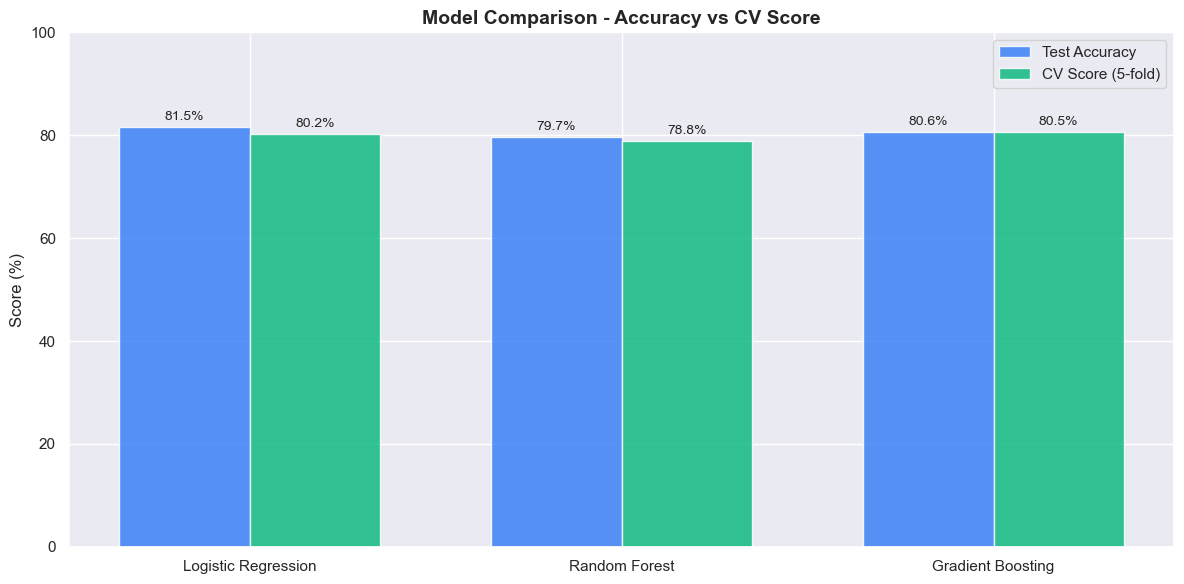

In [7]:
# Model Comparison
model_names = list(results.keys())
accuracies  = [results[m]['accuracy'] * 100 for m in model_names]
cv_scores   = [results[m]['cv_score'] * 100 for m in model_names]

x     = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, accuracies, width, label='Test Accuracy',    color='#3b82f6', alpha=0.85)
bars2 = ax.bar(x + width/2, cv_scores,  width, label='CV Score (5-fold)', color='#10b981', alpha=0.85)
ax.bar_label(bars1, fmt='{:.1f}%', padding=3, fontsize=10)
ax.bar_label(bars2, fmt='{:.1f}%', padding=3, fontsize=10)
ax.set_title('Model Comparison - Accuracy vs CV Score', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 100)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(f'{OUT}/model_comparison.png', dpi=150)
plt.show()

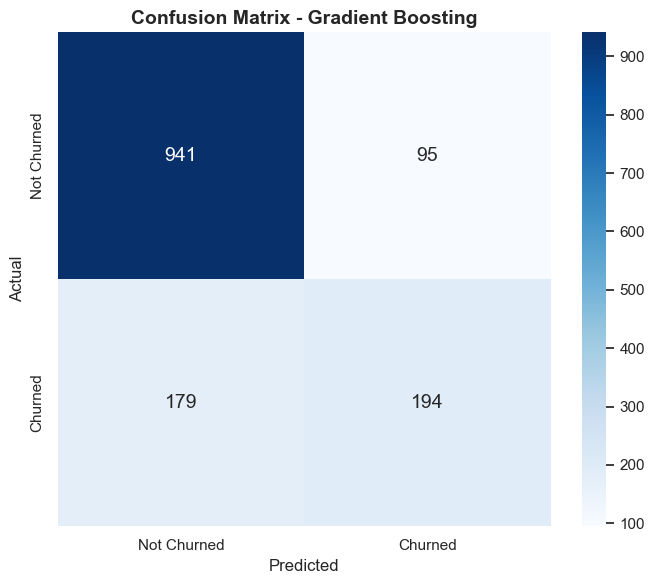

In [8]:
# Confusion Matrix - Best Model
best_name = max(results, key=lambda x: results[x]['cv_score'])
best_pred = results[best_name]['pred']
cm = confusion_matrix(y_test, best_pred)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'],
            annot_kws={'size': 14})
ax.set_title(f'Confusion Matrix - {best_name}', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig(f'{OUT}/confusion_matrix.png', dpi=150)
plt.show()

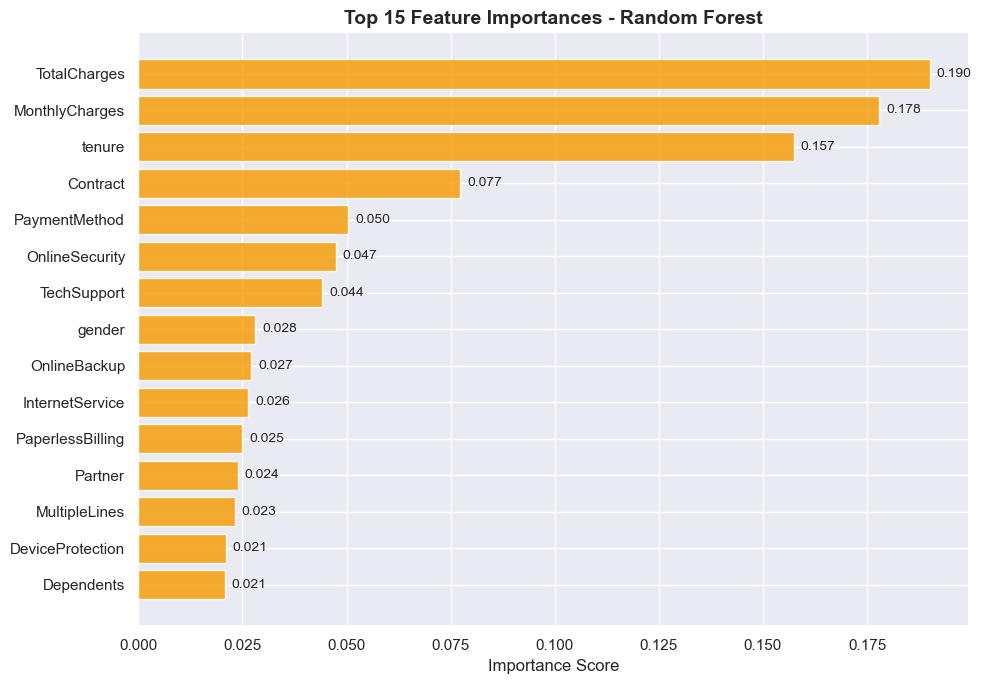

In [9]:
# Feature Importance - Random Forest
rf_model   = results['Random Forest']['model']
importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(importance.index[::-1], importance.values[::-1], color='#f59e0b', alpha=0.85)
ax.bar_label(bars, fmt='{:.3f}', padding=5, fontsize=10)
ax.set_title('Top 15 Feature Importances - Random Forest', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig(f'{OUT}/feature_importance.png', dpi=150)
plt.show()

## 6. Key Statistics

In [10]:
best_name = max(results, key=lambda x: results[x]['cv_score'])

print('=' * 50)
print('       CHURNGUARD - KEY STATISTICS')
print('=' * 50)
print(f'  Total Customers   : {len(df)}')
print(f'  Churn Rate        : {(df["Churn"] == "Yes").mean()*100:.1f}%')
print(f'  Features Used     : {X.shape[1]}')
print(f'  Best Model        : {best_name}')
print(f'  Best Accuracy     : {results[best_name]["accuracy"]*100:.2f}%')
print(f'  Best CV Score     : {results[best_name]["cv_score"]*100:.2f}%')
print('=' * 50)

       CHURNGUARD - KEY STATISTICS
  Total Customers   : 7043
  Churn Rate        : 26.5%
  Features Used     : 19
  Best Model        : Gradient Boosting
  Best Accuracy     : 80.55%
  Best CV Score     : 80.55%


---
**Tools:** Python - Pandas - NumPy - Scikit-learn - Matplotlib - Seaborn  
**Author:** Berke Arda Turk